In [1]:
%load_ext autoreload
%autoreload 2

save_plot = False


: 

In [2]:
import sys
sys.path.append('..')
import pandas as pd 
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from results_analysis_helper import *
import json
import seaborn as sns
pd.set_option('display.max_rows', 100)
plt.rcParams['svg.fonttype'] = 'none'

: 

In [3]:
# gene_perf = pd.read_parquet(f"/cwork/hl489/Pertb_benchmark/DataSet2/gene_perf_combined_all_methods_detail.parquet")
gene_perf = pd.read_parquet(f"/cwork/hl489/Pertb_benchmark/DataSet2/gene_perf_large_detail.parquet")

In [4]:
# new_metrics = compute_new_corr_metrics(
#     gene_perf,
#     deg=[1000, 2000, 5000],
#     sign_tau=0.0,
#     updown_tau=0.0,
#     de_frac=0.1,
#     topk_values=(100,),
    
# )
# new_metrics = pd.read_parquet("new_metrics.parquet")

new_metrics = pd.read_parquet("new_metrics_large_all.parquet")
new_metrics['DataSet'] = new_metrics['DataSet'].replace({
    'HCT_large': 'HCT116',
    'HEK_large': 'HEK293T',
    'K562_large': 'K562',
    'hepg2_large': 'HepG2',
    'jurkat_large': 'Jurkat',
    'rpe1_large': 'RPE1',
})

In [5]:
new_metrics

,DataSet,method,split,perturb,DEG,Nstimulated,Nimputed,metric,performance
0,HCT116,GenePert,0,AARS2,1000,155,155,pearson_distance_raw,0.0047
1,HCT116,GenePert,0,AARS2,1000,155,155,spearman_distance_raw,0.3664
2,HCT116,GenePert,0,AARS2,1000,155,155,pearson_distance_delta,1.0764
3,HCT116,GenePert,0,AARS2,1000,155,155,spearman_distance_delta,1.0049
4,HCT116,GenePert,0,AARS2,1000,155,155,mean_absolute_error_delta,0.0099
...,...,...,...,...,...,...,...,...,...
614650,RPE1,CPA,4,ZNHIT2,5000,81,81,de_auroc_distance_delta,0.3860
614651,RPE1,CPA,4,ZNHIT2,5000,81,81,de_auprc_distance_delta,0.8445
614652,RPE1,CPA,4,ZNHIT2,5000,81,81,topk_jaccard_distance_delta_k100,0.9637
614653,RPE1,CPA,4,ZNHIT2,5000,81,81,topk_precision_distance_delta_k100,0.9300


In [6]:
# # Load split files
# splits = {}
# for s in range(5):
#     with open(f'/cwork/hl489/perturbBench/small_splits/split{s}.json') as f:
#         splits[s] = json.load(f)

# psi_all_deg = []
# for deg in [1000, 2000]:
#     gp_tm = gene_perf[(gene_perf['method'] == 'trainMean') & (gene_perf['deg_rank'] <= deg)].copy()

#     rows = []
#     for split_idx in range(5):
#         train_perts = set(splits[split_idx]['train'])

#         gp_test = gp_tm[(gp_tm['split'] == split_idx)].copy()

#         other_splits = gp_tm[gp_tm['split'] != split_idx]
#         train_data = other_splits[other_splits['perturbation'].isin(train_perts)]

#         gene_avg = (train_data
#             .groupby(['dataset', 'gene'])['mean_true_delta']
#             .mean()
#             .rename('avg_gene_delta')
#         )

#         gp_test = gp_test.merge(gene_avg, on=['dataset', 'gene'], how='left')
#         gp_test['residual'] = gp_test['mean_true_delta'] - gp_test['avg_gene_delta']
#         rows.append(gp_test)

#     gp_all = pd.concat(rows, ignore_index=True)

#     def compute_psi_components(g):
#         x = g['mean_true_delta'].values
#         m = g['avg_gene_delta'].values
#         mask = ~np.isnan(x) & ~np.isnan(m)
#         x, m = x[mask], m[mask]
#         if len(x) < 2:
#             return pd.Series({'PSI': np.nan, 'var_x': np.nan, 'var_m': np.nan, 'cov_xm': np.nan})
#         var_x = np.var(x, ddof=1)
#         var_m = np.var(m, ddof=1)
#         cov_xm = np.cov(x, m, ddof=1)[0, 1]
#         psi = np.var(x - m, ddof=1) / var_x if var_x > 0 else np.nan
#         return pd.Series({'PSI': psi, 'var_x': var_x, 'var_m': var_m, 'cov_xm': cov_xm})

#     psi_deg = (gp_all
#         .groupby(['dataset', 'perturbation'])
#         .apply(compute_psi_components, include_groups=False)
#         .reset_index()
#     )
#     psi_deg['DEG'] = deg
#     psi_all_deg.append(psi_deg)
#     print(f"DEG={deg}: {len(psi_deg)} entries, {psi_deg['PSI'].notna().sum()} non-null")

# psi_all_deg = pd.concat(psi_all_deg, ignore_index=True)

# # Keep DEG=2000 as the default — per cell line
# psi = psi_all_deg[psi_all_deg['DEG'] == 2000].drop(columns='DEG').reset_index(drop=True)

psi_nosplit = []
for deg in [10000]:
    gp_tm = gene_perf[(gene_perf['method'] == 'trainMean') & (gene_perf['deg_rank'] <= deg)].copy()

    # M = mean delta across ALL perturbations per (dataset, gene) — no split holdout
    gene_avg = (gp_tm
        .groupby(['dataset', 'gene'])['mean_true_delta']
        .mean()
        .rename('avg_gene_delta')
    )

    gp_merged = gp_tm.merge(gene_avg, on=['dataset', 'gene'], how='left')
    gp_merged['residual'] = gp_merged['mean_true_delta'] - gp_merged['avg_gene_delta']

    def compute_psi_components(g):
        x = g['mean_true_delta'].values
        m = g['avg_gene_delta'].values
        mask = ~np.isnan(x) & ~np.isnan(m)
        x, m = x[mask], m[mask]
        if len(x) < 2:
            return pd.Series({'PSI': np.nan, 'var_x': np.nan, 'var_m': np.nan, 'cov_xm': np.nan, 'corr_xm': np.nan})
        var_x = np.var(x, ddof=1)
        var_m = np.var(m, ddof=1)
        cov_xm = np.cov(x, m, ddof=1)[0, 1]
        corr_xm = cov_xm / np.sqrt(var_x * var_m) if var_x > 0 and var_m > 0 else np.nan
        psi = np.var(x - m, ddof=1) / var_x if var_x > 0 else np.nan
        return pd.Series({'PSI': psi, 'var_x': var_x, 'var_m': var_m, 'cov_xm': cov_xm, 'corr_xm': corr_xm})


    psi_deg = (gp_merged
        .groupby(['dataset', 'perturbation'])
        .apply(compute_psi_components, include_groups=False)
        .reset_index()
    )
    psi_deg['DEG'] = deg
    psi_nosplit.append(psi_deg)
    print(f"DEG={deg}: {len(psi_deg)} entries")

psi_nosplit = pd.concat(psi_nosplit, ignore_index=True)
psi_ns = psi_nosplit[psi_nosplit['DEG'] == 2000].drop(columns='DEG').reset_index(drop=True)

# Verify Var(M) is constant per dataset
print("\nVar(M) per dataset (should be constant):")
print(psi_ns.groupby('dataset')['var_m'].std())





DEG=10000: 13659 entries

Var(M) per dataset (should be constant):
Series([], Name: var_m, dtype: float64)


In [7]:
psi_ns = psi_nosplit[psi_nosplit['DEG'] == 10000].drop(columns='DEG').reset_index(drop=True)

# Verify Var(M) is constant per dataset
print("\nVar(M) per dataset (should be constant):")
print(psi_ns.groupby('dataset')['var_m'].std())


Var(M) per dataset (should be constant):
dataset
HCT_large       3.343666e-12
HEK_large       1.525080e-12
K562_large      1.460448e-11
hepg2_large     5.867258e-11
jurkat_large    2.834177e-11
rpe1_large      1.082452e-10
Name: var_m, dtype: float64


In [8]:
psi = psi_ns

In [9]:
psi_ns

,dataset,perturbation,PSI,var_x,var_m,cov_xm,corr_xm
0,HCT_large,AAAS,1.450360,0.000560,0.000148,-0.000052,-0.181391
1,HCT_large,AAMP,0.870362,0.003472,0.000148,0.000299,0.417297
2,HCT_large,AAR2,0.989948,0.001183,0.000148,0.000080,0.191010
3,HCT_large,AARS2,1.347654,0.000475,0.000148,-0.000009,-0.032873
4,HCT_large,AATF,0.905949,0.003755,0.000148,0.000251,0.336206
...,...,...,...,...,...,...,...
13654,rpe1_large,ZNHIT6,0.522094,0.031773,0.004011,0.009598,0.850197
13655,rpe1_large,ZRANB2,2.214764,0.003398,0.004011,-0.000059,-0.015862
13656,rpe1_large,ZRSR2,3.613154,0.002281,0.004011,-0.000974,-0.322195
13657,rpe1_large,ZW10,0.718647,0.008573,0.004011,0.003211,0.547667


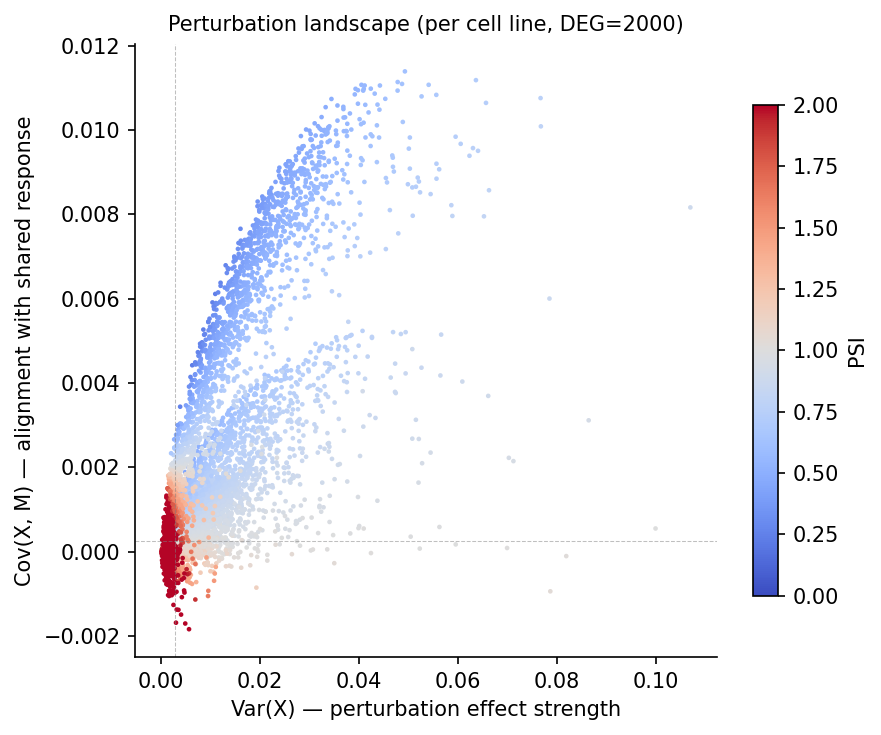

In [10]:
# 2D scatter: Var(X) vs Cov(X,M), colored by PSI
fig, ax = plt.subplots(figsize=(6, 5), dpi=150)

sc = ax.scatter(psi['var_x'], psi['cov_xm'], c=psi['PSI'],
                cmap='coolwarm', s=5, alpha=1, edgecolors='none',
                vmin=0, vmax=2)

plt.colorbar(sc, ax=ax, label='PSI', shrink=0.8)
ax.set_xlabel('Var(X) — perturbation effect strength', fontsize=10)
ax.set_ylabel('Cov(X, M) — alignment with shared response', fontsize=10)
ax.set_title('Perturbation landscape (per cell line, DEG=2000)', fontsize=10)

# Add quadrant lines at medians
ax.axhline(psi['cov_xm'].median(), color='grey', linestyle='--', linewidth=0.5, alpha=0.5)
ax.axvline(psi['var_x'].median(), color='grey', linestyle='--', linewidth=0.5, alpha=0.5)

# Label quadrants
kw = dict(fontsize=7, ha='center', alpha=1)
xlo, xhi = psi['var_x'].quantile(0.15), psi['var_x'].quantile(0.85)
ylo, yhi = psi['cov_xm'].quantile(0.15), psi['cov_xm'].quantile(0.85)
# ax.text(xhi, yhi, 'Sledgehammers\n(strong + generic)', **kw)
# ax.text(xhi, ylo, 'Scalpels\n(strong + distinct)', **kw)
# ax.text(xlo, yhi, 'Weak generic', **kw)
# ax.text(xlo, ylo, 'Weak subtle', **kw)

sns.despine(ax=ax)
plt.tight_layout()
plt.show()


In [11]:
# Split by median into quadrants
var_x_med = psi_ns['var_x'].median()
corr_xm_med = psi_ns['corr_xm'].median()

def assign_quadrant(row):
    hi_var = row['var_x'] > var_x_med
    hi_corr = row['corr_xm'] > corr_xm_med
    if hi_var and hi_corr: return 'Sledgehammer (strong + generic)'
    elif hi_var and not hi_corr: return 'Scalpel (strong + distinct)'
    elif not hi_var and hi_corr: return 'Weak generic'
    else: return 'Weak subtle'

psi_ns['quadrant'] = psi_ns.apply(assign_quadrant, axis=1)

print(psi_ns['quadrant'].value_counts())
print(f"\nMedian Var(X): {var_x_med:.6f}")
print(f"Median Corr(X,M): {corr_xm_med:.4f}")


quadrant
Weak subtle                        5038
Sledgehammer (strong + generic)    5037
Weak generic                       1792
Scalpel (strong + distinct)        1792
Name: count, dtype: int64

Median Var(X): 0.002825
Median Corr(X,M): 0.2906


In [22]:
# Look at which perturbations consistently fall in each quadrant across cell lines
quad_counts = (psi_ns
    .groupby(['perturbation', 'quadrant'])
    .size()
    .unstack(fill_value=0)
)
quad_counts['dominant'] = quad_counts.idxmax(axis=1)
quad_counts['n_celllines'] = quad_counts.drop(columns='dominant').sum(axis=1)

# Perturbations that are in the same quadrant across all cell lines
consistent = quad_counts[quad_counts.max(axis=1, numeric_only=True) == quad_counts['n_celllines']]
print(f"\nConsistently in same quadrant across all cell lines: {len(consistent)}")
print(consistent['dominant'].value_counts())



Consistently in same quadrant across all cell lines: 2278
dominant
Sledgehammer (strong + generic)    1063
Weak subtle                         853
Scalpel (strong + distinct)         260
Weak generic                        102
Name: count, dtype: int64


In [27]:
# Top examples per quadrant (sorted appropriately)
sort_config = {
    'Sledgehammer (strong + generic)': ('cov_xm', False),   # highest cov
    'Scalpel (strong + distinct)':     ('cov_xm', True),    # lowest cov (most distinct)
    'Weak generic':                    ('cov_xm', False),   # highest cov among weak
    'Weak subtle':                     ('cov_xm', True),    # lowest cov among weak
}

for q, (sort_col, asc) in sort_config.items():
    perts = consistent[consistent['dominant'] == q].index.tolist()
    print(f"\n--- {q} ({len(perts)} perturbations) ---")
    sub = psi_ns[psi_ns['perturbation'].isin(perts)].groupby('perturbation')[['var_x', 'cov_xm', 'PSI']].median()
    print(sub.sort_values(sort_col, ascending=asc).head(50))




--- Sledgehammer (strong + generic) (1063 perturbations) ---
                 var_x    cov_xm       PSI
perturbation                              
MED30         0.025457  0.002608  0.823780
MED9          0.020744  0.002179  0.809916
MED21         0.016007  0.002046  0.822066
MED7          0.020153  0.002016  0.789561
EIF2B3        0.020733  0.001952  0.808350
SMC3          0.015199  0.001947  0.869575
MED17         0.014632  0.001818  0.809150
EXOSC2        0.014103  0.001773  0.839369
EXOSC8        0.012537  0.001760  0.833008
TAF12         0.017434  0.001737  0.846876
SUPT5H        0.025646  0.001736  0.837653
MED6          0.011078  0.001732  0.775088
EXOSC9        0.012553  0.001731  0.843000
EIF2B2        0.014155  0.001713  0.795178
EXOSC3        0.013238  0.001678  0.849634
EIF3D         0.014267  0.001650  0.801053
EXOSC4        0.012655  0.001647  0.856947
MED19         0.008362  0.001638  0.761887
RPL17         0.026449  0.001612  0.853335
HSPA9         0.015038  0.001608  0

In [16]:
counts = psi.groupby('perturbation')['dataset'].nunique()
shared = counts[counts == 6].index
psi = psi[psi.perturbation.isin(shared)]

In [23]:
psi.perturbation.nunique()

2269

In [10]:
rename_map = {
    'HCT_large': 'HCT116',
    'HEK_large': 'HEK293T',
    'K562_large': 'K562',
    'hepg2_large': 'HepG2',
    'jurkat_large': 'Jurkat',
    'rpe1_large': 'RPE1',
}
psi['dataset'] = psi['dataset'].replace(rename_map)
psi_all_deg['dataset'] = psi_all_deg['dataset'].replace({
    'HCT_large': 'HCT116',
    'HEK_large': 'HEK293T',
    'K562_large': 'K562',
    'hepg2_large': 'HepG2',
    'jurkat_large': 'Jurkat',
    'rpe1_large': 'RPE1',
})


In [11]:
save_plot = False

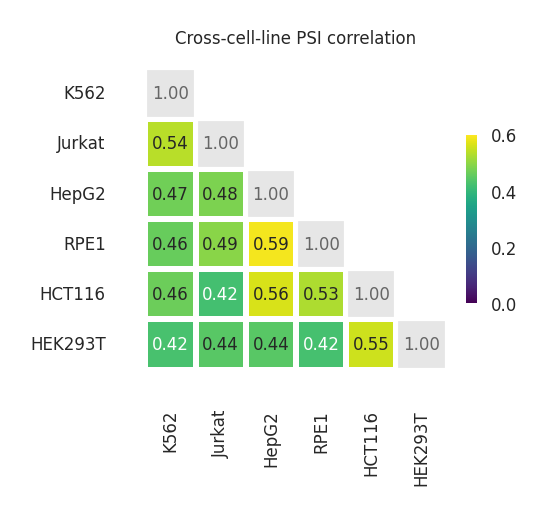

In [12]:
import itertools
from scipy.stats import spearmanr

cell_lines_order = ['K562', 'Jurkat', 'HepG2', 'RPE1', 'HCT116', 'HEK293T']

# rename_map = {'hepg2': 'HepG2', 'jurkat': 'Jurkat', 'rpe1': 'RPE1'}
# psi['dataset'] = psi['dataset'].replace(rename_map)


# Pivot: perturbations × cell lines
psi_pivot = psi.pivot(index='perturbation', columns='dataset', values='PSI')[cell_lines_order].dropna()

# Build correlation matrix
rho_mat = pd.DataFrame(np.ones((len(cell_lines_order), len(cell_lines_order))),
                        index=cell_lines_order, columns=cell_lines_order)
for a, b in itertools.combinations(cell_lines_order, 2):
    rho, _ = spearmanr(psi_pivot[a], psi_pivot[b])
    rho_mat.loc[a, b] = rho
    rho_mat.loc[b, a] = rho

# Use fixed order (no clustering)
rho_ordered = rho_mat

# Lower triangle mask (hide upper triangle + diagonal)
mask_lower = np.triu(np.ones_like(rho_ordered, dtype=bool))

sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(2, 2), dpi=300)
sns.heatmap(rho_ordered, annot=True, fmt='.2f', cmap='viridis', ax=ax,
            mask=mask_lower, vmin=0.0, vmax=0.6,
            linewidths=1, linecolor='white', square=True,
            annot_kws={'fontsize': 4},
            cbar_kws={'shrink': 0.4, 'aspect': 15})

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=4, length=0)
cbar.set_label('')

n = len(cell_lines_order)
# Cover upper triangle with white
for i in range(n):
    for j in range(i + 1, n):
        ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True, color='white', lw=0))

# Draw grey diagonal cells with "1.00" text
for i in range(n):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=True, color='0.9', lw=1, ec='white'))
    ax.text(i + 0.5, i + 0.5, '1.00', ha='center', va='center', fontsize=4, color='0.4')

ax.set_title('Cross-cell-line PSI correlation', fontsize=4)
ax.tick_params(labelsize=4)
plt.tight_layout()
if save_plot:
    plt.savefig('Fig2/Fig2A_PSI_cellline_corr.png', bbox_inches='tight', dpi=300)
    plt.savefig('Fig2/Fig2A_PSI_cellline_corr.svg', bbox_inches='tight')
plt.show()

In [13]:
# Build correlation and p-value matrices
rho_mat = pd.DataFrame(np.ones((len(cell_lines_order), len(cell_lines_order))),
                        index=cell_lines_order, columns=cell_lines_order)
p_mat = pd.DataFrame(np.zeros((len(cell_lines_order), len(cell_lines_order))),
                      index=cell_lines_order, columns=cell_lines_order)

for a, b in itertools.combinations(cell_lines_order, 2):
    rho, pval = spearmanr(psi_pivot[a], psi_pivot[b])
    rho_mat.loc[a, b] = rho
    rho_mat.loc[b, a] = rho
    p_mat.loc[a, b] = pval
    p_mat.loc[b, a] = pval

print(p_mat)


                  K562         Jurkat          HepG2           RPE1  \
K562      0.000000e+00  3.523825e-169  9.570799e-125  6.119488e-120   
Jurkat   3.523825e-169   0.000000e+00  1.022179e-131  1.537375e-139   
HepG2    9.570799e-125  1.022179e-131   0.000000e+00  2.201445e-211   
RPE1     6.119488e-120  1.537375e-139  2.201445e-211   0.000000e+00   
HCT116   1.044057e-121   9.021404e-98  2.157534e-190  2.310814e-162   
HEK293T  8.236514e-100  7.735250e-110  2.061599e-110   3.347485e-99   

                HCT116        HEK293T  
K562     1.044057e-121  8.236514e-100  
Jurkat    9.021404e-98  7.735250e-110  
HepG2    2.157534e-190  2.061599e-110  
RPE1     2.310814e-162   3.347485e-99  
HCT116    0.000000e+00  1.827028e-182  
HEK293T  1.827028e-182   0.000000e+00  


In [14]:
cell_lines_raw = ['HCT116', 'HEK293T', 'K562', 'hepg2', 'jurkat', 'rpe1']

# rename_map = {'hepg2': 'HepG2', 'jurkat': 'Jurkat', 'rpe1': 'RPE1'}
# psi_all_deg['dataset'] = psi_all_deg['dataset'].replace(rename_map)
cell_lines_w = ['K562', 'Jurkat', 'HepG2', 'RPE1', 'HCT116', 'HEK293T']

w_records = []
for deg in [1000, 2000, 5000]:
    psi_deg = psi_all_deg[psi_all_deg['DEG'] == deg]
    pivot = psi_deg.pivot(index='perturbation', columns='dataset', values='PSI')[cell_lines_w].dropna()

    ranks = pivot.rank(axis=0)
    n = len(ranks)
    k = len(cell_lines_w)
    rank_sums = ranks.sum(axis=1)
    S = ((rank_sums - rank_sums.mean()) ** 2).sum()
    W = 12 * S / (k**2 * (n**3 - n))
    w_records.append({'DEG': deg, 'W': W, 'n': n})

w_df = pd.DataFrame(w_records)
print(w_df)

sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(1.5, 1.5), dpi=300)
sns.barplot(data=w_df, x='DEG', y='W', color='#386cb0', edgecolor='0.3', linewidth=0.5, ax=ax)
for i, row in w_df.iterrows():
    ax.text(i, row['W'] + 0.01, f'{row["W"]:.3f}', ha='center', fontsize=4)
ax.set_ylim(0, min(1, w_df['W'].max() + 0.1))
ax.set_xlabel('DEG', fontsize=5)
ax.set_ylabel("Kendall's W", fontsize=5)
ax.set_title("Cross-cell-line PSI agreement", fontsize=5)
ax.tick_params(axis='x', rotation=0, labelsize=5)
ax.tick_params(axis='y', labelsize=5, direction='out', length=4, width=0.8)

sns.despine(ax=ax, top=True, right=True)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

plt.tight_layout()
if save_plot:
    plt.savefig('Fig2/Fig2A_PSI_kendall_w.png', bbox_inches='tight', dpi=300)
    plt.savefig('Fig2/Fig2A_PSI_kendall_w.svg', bbox_inches='tight')
plt.show()


KeyError: "None of [Index(['K562', 'Jurkat', 'HepG2', 'RPE1', 'HCT116', 'HEK293T'], dtype='object', name='dataset')] are in the [columns]"

In [27]:
# # Average PSI and spearman_corr_delta across cell lines for each perturbation
# avg_across_cl = merged.groupby('perturbation')[['PSI', 'spearman_corr_delta']].mean().reset_index()

# rho, pval = spearmanr(avg_across_cl['PSI'], avg_across_cl['spearman_corr_delta'])

# fig, ax = plt.subplots(figsize=(1.5, 1.5), dpi=300)
# ax.scatter(avg_across_cl['PSI'], avg_across_cl['spearman_corr_delta'], s=2, alpha=0.8, edgecolors='none', c='#386cb0')
# ax.set_xlabel('PSI', fontsize=5)
# ax.set_ylabel('trainMean Spearman', fontsize=5)
# ax.set_title(f'Avg across cell lines (ρ={rho:.2f})', fontsize=5)

# ax.tick_params(labelsize=4, length=2, width=0.5)
# sns.despine(ax=ax, top=True, right=True)
# ax.spines['left'].set_linewidth(0.5)
# ax.spines['bottom'].set_linewidth(0.5)
# plt.tight_layout()
# # if save_plot:
# #     plt.savefig('Fig2/Fig2A_PSI_vs_spearman_avg.png', bbox_inches='tight', dpi=300)
# #     plt.savefig('Fig2/Fig2A_PSI_vs_spearman_avg.svg', bbox_inches='tight')
# plt.show()

# print(f'Spearman ρ = {rho:.3f}, p = {pval:.2e}, n = {len(avg_across_cl)} perturbations')


In [29]:
save_plot = False

In [39]:
spd

,DataSet,method,split,perturb,DEG,Nstimulated,Nimputed,metric,performance
102258,HCT116,trainMean,0,AARS2,2000,155,155,spearman_distance_delta,1.1181
102303,HCT116,trainMean,0,ABCB7,2000,112,112,spearman_distance_delta,0.7723
102348,HCT116,trainMean,0,ABCF1,2000,122,122,spearman_distance_delta,1.2043
102393,HCT116,trainMean,0,ABHD17A,2000,301,301,spearman_distance_delta,1.1184
102438,HCT116,trainMean,0,ACOT12,2000,183,183,spearman_distance_delta,1.0656
...,...,...,...,...,...,...,...,...,...
1228967,RPE1,trainMean,4,ZMAT5,2000,50,50,spearman_distance_delta,0.2025
1229012,RPE1,trainMean,4,ZNF100,2000,172,172,spearman_distance_delta,1.0411
1229057,RPE1,trainMean,4,ZNF574,2000,168,168,spearman_distance_delta,0.2033
1229102,RPE1,trainMean,4,ZNF658,2000,68,68,spearman_distance_delta,1.1626


In [41]:
spd_avg

,DataSet,method,split,perturb,DEG,Nstimulated,Nimputed,metric,performance
102258,HCT116,trainMean,0,AARS2,2000,155,155,spearman_distance_delta,1.1181
102303,HCT116,trainMean,0,ABCB7,2000,112,112,spearman_distance_delta,0.7723
102348,HCT116,trainMean,0,ABCF1,2000,122,122,spearman_distance_delta,1.2043
102393,HCT116,trainMean,0,ABHD17A,2000,301,301,spearman_distance_delta,1.1184
102438,HCT116,trainMean,0,ACOT12,2000,183,183,spearman_distance_delta,1.0656
...,...,...,...,...,...,...,...,...,...
1228967,RPE1,trainMean,4,ZMAT5,2000,50,50,spearman_distance_delta,0.2025
1229012,RPE1,trainMean,4,ZNF100,2000,172,172,spearman_distance_delta,1.0411
1229057,RPE1,trainMean,4,ZNF574,2000,168,168,spearman_distance_delta,0.2033
1229102,RPE1,trainMean,4,ZNF658,2000,68,68,spearman_distance_delta,1.1626


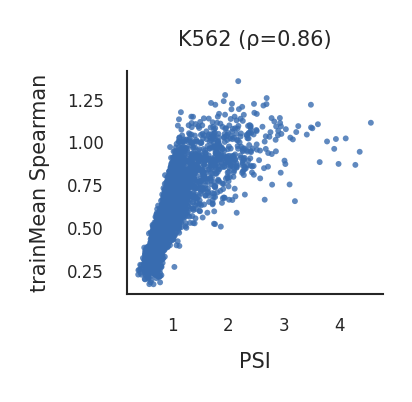

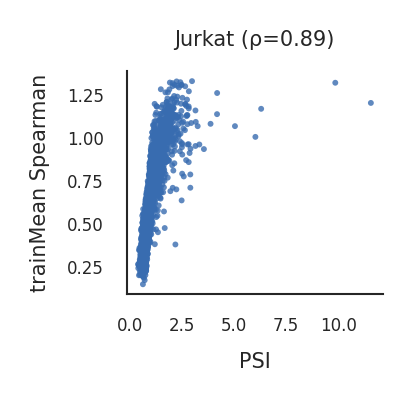

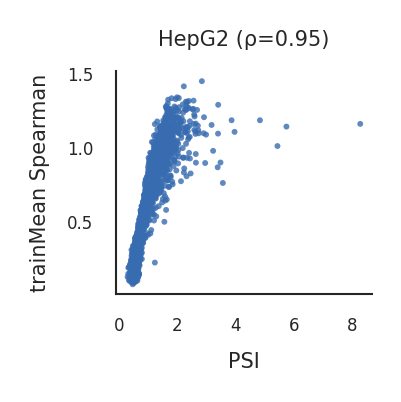

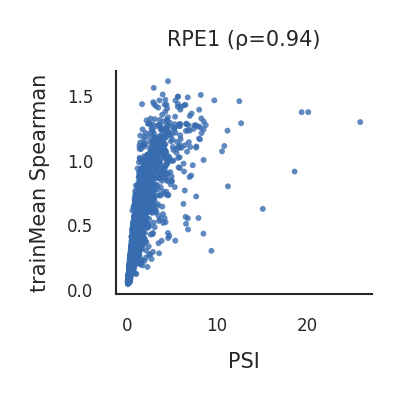

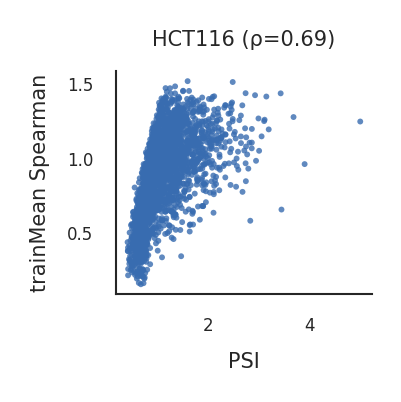

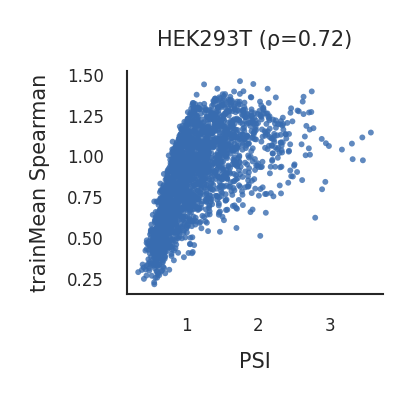

In [44]:
# Get spearman_distance_delta for trainMean at DEG=2000, averaged across splits
spd = new_metrics[
    (new_metrics['method'] == 'trainMean') &
    (new_metrics['DEG'] == 2000) &
    (new_metrics['metric'] == 'spearman_distance_delta')
].copy()

rename_map_nm = {'hepg2': 'HepG2', 'jurkat': 'Jurkat', 'rpe1': 'RPE1'}
spd['DataSet'] = spd['DataSet'].replace(rename_map_nm)

spd_avg = spd.groupby(['DataSet', 'perturb'])['performance'].mean().reset_index()
spd_avg.columns = ['dataset', 'perturbation', 'spearman_corr_delta']
spd_avg['spearman_corr_delta'] = spd_avg['spearman_corr_delta']

# Merge with PSI
merged = psi.merge(spd_avg, on=['dataset', 'perturbation'], how='inner')

cell_lines_order = ['K562', 'Jurkat', 'HepG2', 'RPE1', 'HCT116', 'HEK293T']

shared_perts = merged.groupby('perturbation')['dataset'].nunique()
shared_perts = shared_perts[shared_perts == len(cell_lines_order)].index
merged = merged[merged['perturbation'].isin(shared_perts)]

sns.set_theme(style="white")
for cl in cell_lines_order:
    sub = merged[merged['dataset'] == cl].dropna()
    rho, pval = spearmanr(sub['PSI'], sub['spearman_corr_delta'])

    fig, ax = plt.subplots(figsize=(1.5, 1.5), dpi=300)
    ax.scatter(sub['PSI'], sub['spearman_corr_delta'], s=2, alpha=0.8, edgecolors='none', c='#386cb0')
    ax.set_xlabel('PSI', fontsize=5)
    ax.set_ylabel('trainMean Spearman', fontsize=5)
    ax.set_title(f'{cl} (ρ={rho:.2f})', fontsize=5)

    ax.tick_params(labelsize=4, length=2, width=0.5)
    sns.despine(ax=ax, top=True, right=True)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    plt.tight_layout()
    if save_plot:
        plt.savefig(f'Fig2/Fig2A_PSI_vs_spearman_{cl}.png', bbox_inches='tight', dpi=300)
        plt.savefig(f'Fig2/Fig2A_PSI_vs_spearman_{cl}.svg', bbox_inches='tight')
    plt.show()

In [36]:
spd_avg

,dataset,perturbation,spearman_corr_delta
0,HCT116,AAAS,1.2216
1,HCT116,AAMP,0.9120
2,HCT116,AAR2,1.1431
3,HCT116,AARS2,1.1181
4,HCT116,AATF,0.9199
...,...,...,...
13654,RPE1,ZNHIT6,0.1168
13655,RPE1,ZRANB2,1.0297
13656,RPE1,ZRSR2,1.4735
13657,RPE1,ZW10,0.3438


In [46]:
merged

,perturbation,mean_effect,var_effect,spearman_corr_delta


In [49]:
gene_perf

,dataset,method,split,perturbation,gene,mean_pred,mean_true,mean_pred_delta,mean_true_delta,var_pred,var_true,abs_error,squared_error,abs_error_delta,squared_error_delta,deg_rank,n_stim_cells,n_imp_cells
0,hepg2_large,trainMean,0,TOPBP1,ENSG00000125804,0.065882,0.000000,0.003495,-0.062388,0.0,0.000000,0.065882,0.004340,0.065882,0.004340,1,37,37
1,hepg2_large,trainMean,0,TOPBP1,ENSG00000163638,0.045080,0.000000,-0.008818,-0.053898,0.0,0.000000,0.045080,0.002032,0.045080,0.002032,2,37,37
2,hepg2_large,trainMean,0,TOPBP1,ENSG00000248323,0.053642,0.000000,0.001419,-0.052223,0.0,0.000000,0.053642,0.002877,0.053642,0.002877,3,37,37
3,hepg2_large,trainMean,0,TOPBP1,ENSG00000169105,0.065600,0.004025,-0.003892,-0.065468,0.0,0.000583,0.061576,0.003792,0.061576,0.003792,4,37,37
4,hepg2_large,trainMean,0,TOPBP1,ENSG00000163781,0.219748,0.042942,-0.036695,-0.213501,0.0,0.016727,0.176806,0.031260,0.176806,0.031260,5,37,37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177722011,HEK_large,GenePert,4,ZNHIT2,FAM181A,0.000066,0.000000,0.000066,0.000000,0.0,0.000000,0.000066,0.000000,0.000066,0.000000,7115,82,82
177722012,HEK_large,GenePert,4,ZNHIT2,CAPSL,0.000202,0.000000,0.000202,0.000000,0.0,0.000000,0.000202,0.000000,0.000202,0.000000,7116,82,82
177722013,HEK_large,GenePert,4,ZNHIT2,ENSG00000233616,-0.000077,0.000000,-0.000077,0.000000,0.0,0.000000,0.000077,0.000000,0.000077,0.000000,7117,82,82
177722014,HEK_large,GenePert,4,ZNHIT2,LINC01939,0.000049,0.000000,0.000049,0.000000,0.0,0.000000,0.000049,0.000000,0.000049,0.000000,7118,82,82


In [53]:
save_plot = True

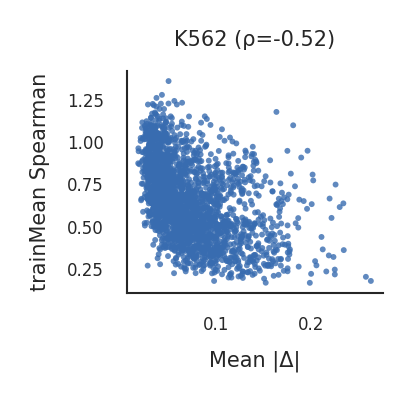

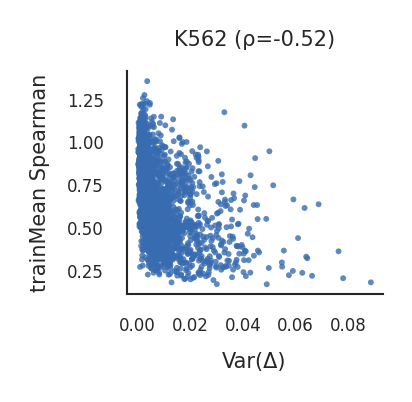

In [54]:
# Compute per-perturbation summaries at DEG=2000, K562 only
gp_tm = gene_perf[
    (gene_perf['method'] == 'trainMean') &
    (gene_perf['deg_rank'] <= 2000) &
    (gene_perf['dataset'] == 'K562_large')
].copy()

pert_stats = (gp_tm
    .groupby('perturbation')['mean_true_delta']
    .agg(mean_effect=lambda x: x.abs().mean(), var_effect='var')

    .reset_index()
)

# Get spearman for K562
spd_k562 = spd_avg[spd_avg['dataset'] == 'K562'].copy()

# Merge
merged = pert_stats.merge(spd_k562[['perturbation', 'spearman_corr_delta']], on='perturbation', how='inner')

sns.set_theme(style="white")
for metric, label in [('mean_effect', 'Mean |Δ|'), ('var_effect', 'Var(Δ)')]:
    sub = merged.dropna(subset=[metric, 'spearman_corr_delta'])
    rho, _ = spearmanr(sub[metric], sub['spearman_corr_delta'])

    fig, ax = plt.subplots(figsize=(1.5, 1.5), dpi=300)
    ax.scatter(sub[metric], sub['spearman_corr_delta'], s=2, alpha=0.8, edgecolors='none', c='#386cb0')
    ax.set_xlabel(label, fontsize=5)
    ax.set_ylabel('trainMean Spearman', fontsize=5)
    ax.set_title(f'K562 (ρ={rho:.2f})', fontsize=5)

    ax.tick_params(labelsize=4, length=2, width=0.5)
    sns.despine(ax=ax, top=True, right=True)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    plt.tight_layout()
    if save_plot:
        plt.savefig(f'FigSupp/FigSuppA_{metric}_vs_spearman_K562.png', bbox_inches='tight', dpi=300)
        plt.savefig(f'FigSupp/FigSuppA_{metric}_vs_spearman_K562.svg', bbox_inches='tight')
    plt.show()


In [32]:
# ── Hypothesis testing: why does PSI W decrease with DEG? ──

# gp_tm_all = gene_perf[gene_perf['method'] == 'trainMean'].copy()

# # 1. How much variance do genes in different DEG bands contribute?
# # Look at mean_true_delta magnitude by deg_rank band
# gp_tm_all['deg_band'] = pd.cut(gp_tm_all['deg_rank'], bins=[0, 1000, 2000, 5000], labels=['1-1000', '1001-2000', '2001-5000'])

# print("=== Mean |true_delta| by DEG band ===")
# print(gp_tm_all.groupby('deg_band', observed=True)['mean_true_delta'].agg(['mean', 'std', 'median', lambda x: (x.abs()).mean()]))
# print()

# # 2. Variance contribution: for a few example perturbations, 
# #    how much does Var(mean_true_delta) change as we add genes?
# print("=== Var(mean_true_delta) by DEG threshold for sample perturbations ===")
# for ds in ['K562', 'hepg2']:
#     for pert in gp_tm_all[gp_tm_all['dataset']==ds]['perturbation'].unique()[:3]:
#         sub = gp_tm_all[(gp_tm_all['dataset']==ds) & (gp_tm_all['perturbation']==pert)]
#         for deg in [1000, 2000, 5000]:
#             v = sub[sub['deg_rank'] <= deg]['mean_true_delta'].var()
#             print(f"  {ds}/{pert} DEG<={deg}: Var={v:.6f}, n_genes={len(sub[sub['deg_rank']<=deg])}")
#         print()

# # 3. Are PSI values stable across DEG? Compare PSI at different thresholds
# psi_wide = psi_all_deg.pivot_table(index=['dataset', 'perturbation'], columns='DEG', values='PSI')
# print("=== Correlation of PSI across DEG thresholds ===")
# print(psi_wide.corr(method='spearman'))
# print()

# # 4. How much do rankings actually shift?
# # For each cell line, rank perturbations by PSI at each DEG, compare
# print("=== Rank stability (Spearman rho of PSI rankings across DEG, per cell line) ===")
# from scipy.stats import spearmanr
# for ds in psi_all_deg['dataset'].unique():
#     sub = psi_all_deg[psi_all_deg['dataset']==ds].pivot(index='perturbation', columns='DEG', values='PSI').dropna()
#     r_1k_2k, _ = spearmanr(sub[1000], sub[2000])
#     r_2k_5k, _ = spearmanr(sub[2000], sub[5000])
#     r_1k_5k, _ = spearmanr(sub[1000], sub[5000])
#     print(f"  {ds}: 1k-2k={r_1k_2k:.3f}, 2k-5k={r_2k_5k:.3f}, 1k-5k={r_1k_5k:.3f}")


In [33]:
new_metrics[
    (new_metrics['method'] == 'trainMean') &
    (new_metrics['DEG'] == 2000) &
    (new_metrics['metric'] == 'spearman_distance_delta')
].groupby('DataSet').performance.describe()



,count,mean,std,min,25%,50%,75%,max
DataSet,,,,,,,,
HCT116,2272.0,0.881957,0.285364,0.1515,0.675975,0.90555,1.105300,1.5220
HEK293T,2276.0,0.870402,0.259381,0.2154,0.673050,0.88665,1.076125,1.4613
HepG2,2278.0,0.620140,0.314274,0.0781,0.348525,0.60435,0.874000,1.4542
Jurkat,2277.0,0.662679,0.255877,0.1470,0.456000,0.63300,0.856400,1.3309
K562,2278.0,0.646640,0.222768,0.1696,0.479150,0.63345,0.814025,1.3587
RPE1,2278.0,0.436930,0.354091,0.0410,0.165825,0.29645,0.648775,1.6177


In [1]:
# # =========================================================
# # Random-effects meta-analysis for global PSI
# # =========================================================

# def random_effects_pool(log_vals, se_vals):
#     """DerSimonian-Laird random-effects pooling of log(PSI)."""
#     y = np.asarray(log_vals, dtype=float)
#     se = np.asarray(se_vals, dtype=float)

#     m = np.isfinite(y) & np.isfinite(se) & (se > 0)
#     y, se = y[m], se[m]
#     k = len(y)
#     if k == 0:
#         return None

#     v = se**2
#     if k == 1:
#         return {'mu_log': y[0], 'se_mu_log': se[0], 'tau2': 0.0,
#                 'I2_percent': np.nan, 'k_used': 1}

#     w = 1.0 / v
#     mu_fe = np.sum(w * y) / np.sum(w)
#     Q = np.sum(w * (y - mu_fe)**2)
#     C = np.sum(w) - np.sum(w**2) / np.sum(w)
#     tau2 = max(0.0, (Q - (k - 1)) / C) if C > 0 else 0.0

#     w_re = 1.0 / (v + tau2)
#     mu = np.sum(w_re * y) / np.sum(w_re)
#     se_mu = np.sqrt(1.0 / np.sum(w_re))
#     I2 = max(0.0, (Q - (k - 1)) / Q) * 100 if Q > 0 else 0.0

#     return {'mu_log': mu, 'se_mu_log': se_mu, 'tau2': tau2,
#             'I2_percent': I2, 'k_used': k}


# def compute_psi_with_bootstrap(gene_perf, splits, max_deg=2000,
#                                 n_boot=500, random_state=0, min_boot_ok=30):
#     """Per-dataset/per-perturbation PSI with bootstrap SE (split-aware)."""
#     rng = np.random.default_rng(random_state)
#     rows = []

#     for ds in gene_perf['dataset'].dropna().unique():
#         gp_ds = gene_perf[
#             (gene_perf['dataset'] == ds) &
#             (gene_perf['method'] == 'trainMean') &
#             (gene_perf['deg_rank'] <= max_deg)
#         ]

#         for split_idx in range(5):
#             train_perts = set(splits[split_idx]['train'])
#             gp_split = gp_ds[gp_ds['split'] == split_idx]

#             # Test perturbations in this split
#             test_perts = gp_split['perturbation'].unique()

#             # Gene average from training perturbations (from other splits)
#             other = gp_ds[gp_ds['split'] != split_idx]
#             train_data = other[other['perturbation'].isin(train_perts)]
#             gene_avg = train_data.groupby('gene')['mean_true_delta'].mean()

#             for pert in test_perts:
#                 sub = gp_split[gp_split['perturbation'] == pert]
#                 genes_common = sub['gene'][sub['gene'].isin(gene_avg.index)]
#                 sub = sub[sub['gene'].isin(genes_common)]
#                 if len(sub) < 3:
#                     continue

#                 x = sub['mean_true_delta'].to_numpy(dtype=float)
#                 g = gene_avg.loc[sub['gene'].values].to_numpy(dtype=float)

#                 total_var = np.var(x, ddof=1)
#                 if not np.isfinite(total_var) or total_var <= 0:
#                     rows.append({'dataset': ds, 'split': split_idx,
#                                  'perturbation': pert, 'PSI': np.nan,
#                                  'log_PSI': np.nan, 'se_log_PSI': np.nan,
#                                  'n_genes': len(x), 'n_boot_ok': 0})
#                     continue

#                 resid_var = np.var(x - g, ddof=1)
#                 psi_val = resid_var / total_var
#                 log_psi = np.log(psi_val) if np.isfinite(psi_val) and psi_val > 0 else np.nan

#                 # Bootstrap SE for log(PSI)
#                 boot_logs = []
#                 n = len(x)
#                 for _ in range(n_boot):
#                     idx = rng.integers(0, n, size=n)
#                     xb, gb = x[idx], g[idx]
#                     vxb = np.var(xb, ddof=1)
#                     if not np.isfinite(vxb) or vxb <= 0:
#                         continue
#                     sb = np.var(xb - gb, ddof=1) / vxb
#                     if np.isfinite(sb) and sb > 0:
#                         boot_logs.append(np.log(sb))

#                 boot_logs = np.asarray(boot_logs, dtype=float)
#                 se_log = np.std(boot_logs, ddof=1) if len(boot_logs) >= min_boot_ok else np.nan

#                 rows.append({'dataset': ds, 'split': split_idx,
#                              'perturbation': pert, 'PSI': psi_val,
#                              'log_PSI': log_psi, 'se_log_PSI': se_log,
#                              'n_genes': n, 'n_boot_ok': len(boot_logs)})

#     return pd.DataFrame(rows)


# def compute_global_psi(spec_df):
#     """Random-effects pooling across datasets (and splits) per perturbation."""
#     # Average log_PSI and se across splits within each dataset first
#     ds_level = (spec_df.dropna(subset=['log_PSI', 'se_log_PSI'])
#         .groupby(['dataset', 'perturbation'])
#         .agg(log_PSI=('log_PSI', 'mean'),
#              se_log_PSI=('se_log_PSI', lambda x: np.sqrt((x**2).mean())),  # RMS of SEs
#              n_splits=('split', 'count'))
#         .reset_index()
#     )

#     out = []
#     for pert, g in ds_level.groupby('perturbation'):
#         pooled = random_effects_pool(g['log_PSI'], g['se_log_PSI'])
#         if pooled is None:
#             continue
#         mu = pooled['mu_log']
#         se_mu = pooled['se_mu_log']
#         out.append({
#             'perturbation': pert,
#             'global_PSI': np.exp(mu),
#             'ci_low_95': np.exp(mu - 1.96 * se_mu),
#             'ci_high_95': np.exp(mu + 1.96 * se_mu),
#             'k_celltypes': pooled['k_used'],
#             'tau2': pooled['tau2'],
#             'I2_percent': pooled['I2_percent']
#         })

#     return pd.DataFrame(out).sort_values('global_PSI', ascending=False)


# # =========================================================
# # Run
# # =========================================================
# print("Computing per-dataset PSI with bootstrap SEs (this may take a few minutes)...")
# spec_boot = compute_psi_with_bootstrap(gene_perf, splits, max_deg=2000, n_boot=500)
# print(f"  {len(spec_boot)} (dataset, split, perturbation) entries")

# global_psi = compute_global_psi(spec_boot)
# print(f"  {len(global_psi)} perturbations with global PSI")
# print()
# print(global_psi.describe())
# print()
# print(global_psi.sort_values('global_PSI').head(20))

Computing per-dataset PSI with bootstrap SEs (this may take a few minutes)...


NameError: name 'gene_perf' is not defined